### Colab config

In [ ]:
# First cell in Colab
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"GPU name      : {torch.cuda.get_device_name(0)}")
# Should print: Tesla T4 or similar

# Install dependencies
!pip install torchvision torch -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available : True
GPU name      : Tesla T4


### Setting Working Directory

In [ ]:
import os

curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")
os.chdir('/content/drive/MyDrive/BREAST_CANCER_FL/')
print("Changing to root directory...")

print(f"Working in: '{os.getcwd()}'")

Current directory: '/content/drive/My Drive/BREAST_CANCER_FL'
Changing to root directory...
Working in: '/content/drive/MyDrive/BREAST_CANCER_FL'


### Environment Setup & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Set Working Directory
BASE_PATH = '/content/drive/MyDrive/BREAST_CANCER_FL/'
os.chdir(BASE_PATH)
import sys
sys.path.append(BASE_PATH)

from model_architectures import (
    EMBEDDING_DIM,
    Hospital1_MLP, Hospital2_MLP, Hospital3_CNN
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

os.makedirs(os.path.join(BASE_PATH, 'models/federated/fedproto'), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, 'results/federated/fedproto'), exist_ok=True)

print("="*70)
print("  STEP 4 — FedProto (Prototype Representation Sharing) with Fine-Tuning")
print("="*70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Device: cuda
  STEP 4 — FedProto (Prototype Representation Sharing) with Fine-Tuning


### Data Loading

In [ ]:
print("Loading Datasets...")

# Hospital 1 — WDBC
X_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_train.csv')).values
y_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_train.csv')).values.flatten()
X_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_test.csv')).values
y_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_test.csv')).values.flatten()

train_dataset_h1 = TensorDataset(torch.FloatTensor(X_train_h1), torch.FloatTensor(y_train_h1))
test_dataset_h1 = TensorDataset(torch.FloatTensor(X_test_h1), torch.FloatTensor(y_test_h1))
train_loader_h1 = DataLoader(train_dataset_h1, batch_size=32, shuffle=True)
test_loader_h1 = DataLoader(test_dataset_h1, batch_size=32, shuffle=False)

# Hospital 2 — Coimbra
X_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_train.csv')).values
y_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_train.csv')).values.flatten()
X_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_test.csv')).values
y_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_test.csv')).values.flatten()

train_dataset_h2 = TensorDataset(torch.FloatTensor(X_train_h2), torch.FloatTensor(y_train_h2))
test_dataset_h2 = TensorDataset(torch.FloatTensor(X_test_h2), torch.FloatTensor(y_test_h2))
train_loader_h2 = DataLoader(train_dataset_h2, batch_size=16, shuffle=True)
test_loader_h2 = DataLoader(test_dataset_h2, batch_size=16, shuffle=False)

# Hospital 3 — BreakHis
class BreakHisDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform  # <-- This line was missing!
        self.images, self.labels = [], []
        for cls, label in [('benign', 0), ('malignant', 1)]:
            cls_dir = os.path.join(root_dir, cls)
            if os.path.exists(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform_h3 = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(), norm
])
test_transform_h3 = transforms.Compose([transforms.ToTensor(), norm])

train_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/train'), transform=train_transform_h3)
test_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/test'), transform=test_transform_h3)

from sklearn.utils.class_weight import compute_class_weight
class_weights_h3 = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=train_dataset_h3.labels)
sample_weights_h3 = [class_weights_h3[l] for l in train_dataset_h3.labels]
sampler_h3 = WeightedRandomSampler(weights=sample_weights_h3, num_samples=len(sample_weights_h3), replacement=True)

# Optimized DataLoaders for CUDA
train_loader_h3 = DataLoader(train_dataset_h3, batch_size=32, sampler=sampler_h3, num_workers=2, pin_memory=True)
test_loader_h3 = DataLoader(test_dataset_h3, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Data successfully loaded and pinned to memory.")

Loading Datasets...
Data successfully loaded and pinned to memory.


### Creating Directories

In [ ]:
# CREATE DIRECTORIES

os.makedirs('results/synthetic_augmentation', exist_ok=True)
os.makedirs('models/augmented', exist_ok=True)

print(" Directories created")
print(f"   results/synthetic_augmentation/")
print(f"   models/augmented/")

 Directories created
   results/synthetic_augmentation/
   models/augmented/


### Load FedAvg Equal Best Models

In [ ]:
# ============================================================
# LOAD FedAvg EQUAL MODELS - CORRECTED VERSION
# Use hospital*_fedavg_eq.pth (final round models)
# Verify against fl_history_eq.json
# ============================================================
# Load FL history
with open(
    'results/federated/equal/fl_history_eq.json',
    'r', encoding='utf-8'
) as f:
    fl_history_equal = json.load(f)

# --------------------------------------------------------
# Load FINAL ROUND models (not "best" validation models)
# hospital*_fedavg_eq.pth are saved at end of each round
# --------------------------------------------------------
model_h1_base = Hospital1_MLP(
    input_size=23, dropout_rate=0.3
).to(device)
model_h1_base.load_state_dict(
    torch.load(
        'models/federated/equal/hospital1_fedavg_eq.pth',
        map_location=device
    )
)

model_h2_base = Hospital2_MLP(
    input_size=9, dropout_rate=0.3
).to(device)
model_h2_base.load_state_dict(
    torch.load(
        'models/federated/equal/hospital2_fedavg_eq.pth',
        map_location=device
    )
)

model_h3_base = Hospital3_CNN(dropout_rate=0.2).to(device)
model_h3_base.load_state_dict(
    torch.load(
        'models/federated/equal/hospital3_fedavg_eq.pth',
        map_location=device
    )
)

print(" FedAvg Equal models loaded")
print("   Using hospital*_fedavg_eq.pth (final round models)")

# --------------------------------------------------------
# Get metrics from fl_history
# --------------------------------------------------------
h2_accs = fl_history_equal['h2_test_acc']
best_h2_idx = int(np.argmax(h2_accs))
best_h2_acc = h2_accs[best_h2_idx]
best_round = fl_history_equal['round'][best_h2_idx]

print(f"\nFrom fl_history_eq.json:")
print(f"  H2 best accuracy: {best_h2_acc:.4f}")
print(f"  Best round: {best_round}")
print(f"  All H2 accuracies: {h2_accs}")

# --------------------------------------------------------
# Also check best_h*_fedavg_eq.pth models for comparison
# These are checkpoint models, not final round
# --------------------------------------------------------
print(f"\n⚠️  Note:")
print(f"  best_h2_fedavg_eq.pth = checkpoint with best validation loss")
print(f"  hospital2_fedavg_eq.pth = final model after all rounds")
print(f"  We are using hospital2_fedavg_eq.pth (final round)")

# --------------------------------------------------------
# Verify by evaluating loaded model on test set
# --------------------------------------------------------
print(f"\nVerifying loaded models by evaluation...")

def quick_eval(model, dataloader, device):
    criterion = nn.BCEWithLogitsLoss()
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            all_preds.extend((outputs > 0.0).float().cpu().numpy())
            all_probs.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels).flatten()
    all_preds = np.array(all_preds).flatten()

    try:
        auc = roc_auc_score(all_labels, np.array(all_probs).flatten())
    except ValueError:
        auc = 0.0

    return {
        'acc': accuracy_score(all_labels, all_preds),
        'auc': auc
    }

m1 = quick_eval(model_h1_base, test_loader_h1, device)
m2 = quick_eval(model_h2_base, test_loader_h2, device)
m3 = quick_eval(model_h3_base, test_loader_h3, device)

print(f"\nLoaded model evaluation:")
print(f"  H1 Acc={m1['acc']:.4f}")
print(f"  H2 Acc={m2['acc']:.4f} (expected ~0.7917 or close)")
print(f"  H3 Acc={m3['acc']:.4f}")

if m2['acc'] != best_h2_acc:
    print(f"\n  WARNING: Loaded H2 model accuracy {m2['acc']:.4f}")
    print(f"             differs from best in history {best_h2_acc:.4f}")
    print(f"             This means final round != best round")
    print(f"             Using final round model for augmentation")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 81.8MB/s]


✅ FedAvg Equal models loaded
   Using hospital*_fedavg_eq.pth (final round models)

From fl_history_eq.json:
  H2 best accuracy: 0.7917
  Best round: 1.0
  All H2 accuracies: [0.7916666666666666, 0.6666666666666666, 0.625, 0.6666666666666666, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.6666666666666666, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.6666666666666666, 0.75, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.75, 0.7083333333333334, 0.7083333333333334]

⚠️  Note:
  best_h2_fedavg_eq.pth = checkpoint with best validation loss
  hospital2_fedavg_eq.pth = final model after all rounds
  We are using hospital2_fedavg_eq.pth (final round)

Verifying loaded models by evaluation...

Loaded model evaluation:
  H1 Acc=0.9649
  H2 Acc=0.7083 (expected ~0.7917 or close)
  H3 Acc=0.9879

⚠️  WARNING: Loaded H2 model accurac

In [ ]:
import os
print(os.listdir('models/federated/equal/'))

['best_h1_fedavg_eq.pth', 'best_h2_fedavg_eq.pth', 'best_global_shared_head_eq.pth', 'best_h3_fedavg_eq.pth', 'hospital1_fedavg_eq.pth', 'hospital2_fedavg_eq.pth', 'hospital3_fedavg_eq.pth']


### Evaluate Helper Function

In [ ]:
# SHARED EVALUATION FUNCTION
# Used throughout augmentation + SHAP experiments

def evaluate_model(model, dataloader, device):
    criterion = nn.BCEWithLogitsLoss()
    model.eval()
    running_loss = 0.0
    all_preds    = []
    all_probs    = []
    all_labels   = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs  = inputs.to(device).float()
            labels  = labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(
                (outputs > 0.0).float().cpu().numpy()
            )
            all_probs.extend(
                torch.sigmoid(outputs).cpu().numpy()
            )
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels).flatten()
    all_preds  = np.array(all_preds).flatten()
    all_probs  = np.array(all_probs).flatten()

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0

    return {
        'loss'     : running_loss / len(dataloader.dataset),
        'accuracy' : accuracy_score(all_labels, all_preds),
        'precision': precision_score(
            all_labels, all_preds, zero_division=0
        ),
        'recall'   : recall_score(
            all_labels, all_preds, zero_division=0
        ),
        'f1'       : f1_score(
            all_labels, all_preds, zero_division=0
        ),
        'auc_roc'  : auc
    }

# Verify baseline H2 performance
baseline_metrics = evaluate_model(
    model_h2_base, test_loader_h2, device
)
print(" Evaluation function defined")
print(f"\n   H2 Baseline (FedAvg Equal):")
print(f"   Accuracy  : {baseline_metrics['accuracy']:.4f}")
print(f"   F1        : {baseline_metrics['f1']:.4f}")
print(f"   AUC-ROC   : {baseline_metrics['auc_roc']:.4f}")

 Evaluation function defined

   H2 Baseline (FedAvg Equal):
   Accuracy  : 0.7083
   F1        : 0.6957
   AUC-ROC   : 0.7622


### Synthetic Data Generation

In [ ]:
# ============================================================
# SYNTHETIC DATA AUGMENTATION FOR HOSPITAL 2 (COIMBRA)
#
# Strategy:
#   Use Gaussian Mixture Model (GMM) to learn the
#   distribution of Coimbra's blood biomarker data
#   separately per class (benign/malignant)
#   Generate synthetic samples from learned distribution
#   Validate synthetic samples using H1+H3 embeddings
#
# Why GMM not GAN:
#   - 92 samples too small for GAN training (unstable)
#   - GMM well-suited for small tabular datasets
#   - Probabilistic — generates diverse realistic samples
#   - No privacy violation — purely statistical model
# ============================================================
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd

print("="*70)
print("  SYNTHETIC DATA AUGMENTATION — Hospital 2 (Coimbra)")
print("="*70)

# --------------------------------------------------------
# Separate training data by class
# --------------------------------------------------------
X_train_h2_benign    = X_train_h2[y_train_h2 == 0]
X_train_h2_malignant = X_train_h2[y_train_h2 == 1]

print(f"\n  Original class distribution:")
print(f"   Benign    : {len(X_train_h2_benign)} samples")
print(f"   Malignant : {len(X_train_h2_malignant)} samples")
print(f"   Total     : {len(X_train_h2)} samples")

# --------------------------------------------------------
# Fit GMM separately per class
# n_components = 2 for small datasets (avoids overfitting)
# --------------------------------------------------------
gmm_benign    = GaussianMixture(
    n_components=2, covariance_type='full',
    random_state=42, max_iter=200
)
gmm_malignant = GaussianMixture(
    n_components=2, covariance_type='full',
    random_state=42, max_iter=200
)

gmm_benign.fit(X_train_h2_benign)
gmm_malignant.fit(X_train_h2_malignant)

print(f"\n   GMM fitted per class")
print(f"   Benign    GMM converged: {gmm_benign.converged_}")
print(f"   Malignant GMM converged: {gmm_malignant.converged_}")

# --------------------------------------------------------
# Generate synthetic samples
# Target: augment to ~300 total samples (balanced)
# Generate enough to reach 150 per class
# --------------------------------------------------------
n_synthetic_benign    = 150 - len(X_train_h2_benign)
n_synthetic_malignant = 150 - len(X_train_h2_malignant)

# Ensure we generate at least some
n_synthetic_benign    = max(n_synthetic_benign, 50)
n_synthetic_malignant = max(n_synthetic_malignant, 50)

X_syn_benign,    _ = gmm_benign.sample(n_synthetic_benign)
X_syn_malignant, _ = gmm_malignant.sample(n_synthetic_malignant)

y_syn_benign    = np.zeros(n_synthetic_benign)
y_syn_malignant = np.ones(n_synthetic_malignant)

print(f"\n  Synthetic samples generated:")
print(f"   Benign    : {n_synthetic_benign} synthetic")
print(f"   Malignant : {n_synthetic_malignant} synthetic")

# --------------------------------------------------------
# Combine original + synthetic
# --------------------------------------------------------
X_train_h2_aug = np.vstack([
    X_train_h2,
    X_syn_benign,
    X_syn_malignant
])
y_train_h2_aug = np.concatenate([
    y_train_h2,
    y_syn_benign,
    y_syn_malignant
])

# Shuffle
shuffle_idx    = np.random.permutation(len(X_train_h2_aug))
X_train_h2_aug = X_train_h2_aug[shuffle_idx]
y_train_h2_aug = y_train_h2_aug[shuffle_idx]

print(f"\n  Augmented dataset:")
print(f"   Total samples : {len(X_train_h2_aug)}")
print(f"   Benign        : {(y_train_h2_aug==0).sum()}")
print(f"   Malignant     : {(y_train_h2_aug==1).sum()}")
print(f"   Growth ratio  : "
      f"{len(X_train_h2_aug)/len(X_train_h2):.1f}x original")

# --------------------------------------------------------
# Create augmented DataLoader
# --------------------------------------------------------
aug_dataset_h2 = TensorDataset(
    torch.FloatTensor(X_train_h2_aug),
    torch.FloatTensor(y_train_h2_aug)
)
aug_loader_h2 = DataLoader(
    aug_dataset_h2, batch_size=16,
    shuffle=True
)

# Save augmented dataset
pd.DataFrame(X_train_h2_aug).to_csv(
    'data/processed/coimbra/X_train_augmented.csv',
    index=False
)
pd.DataFrame(y_train_h2_aug).to_csv(
    'data/processed/coimbra/y_train_augmented.csv',
    index=False
)

print(f"\n   Augmented datasets saved")
print(f"     data/processed/coimbra/X_train_augmented.csv")

  SYNTHETIC DATA AUGMENTATION — Hospital 2 (Coimbra)

  Original class distribution:
   Benign    : 41 samples
   Malignant : 51 samples
   Total     : 92 samples

   GMM fitted per class
   Benign    GMM converged: True
   Malignant GMM converged: True

  Synthetic samples generated:
   Benign    : 109 synthetic
   Malignant : 99 synthetic

  Augmented dataset:
   Total samples : 300
   Benign        : 150
   Malignant     : 150
   Growth ratio  : 3.3x original

   Augmented datasets saved
     data/processed/coimbra/X_train_augmented.csv


### Validate Synthetic Samples

  SYNTHETIC DATA VALIDATION

  Statistical comparison (original vs synthetic):
  Feature            Orig Mean     Syn Mean   KS p-value
  ───────────────────────────────────────────────────────
  Age                  -0.0000      -0.0326       0.1519 
  BMI                  -0.0000       0.0053       0.5033 
  Glucose               0.0000      -0.1220       0.3023 
  Insulin               0.0000      -0.0933       0.2463 
  HOMA                  0.0000      -0.1155       0.2190 
  Leptin               -0.0000      -0.0574       0.1940 
  Adiponectin           0.0000       0.0387       0.0423 
  Resistin              0.0000       0.0167       0.0247 
  MCP.1                -0.0000       0.0993       0.2113 

  KS test interpretation:
  p > 0.05 → synthetic distribution matches original 
  p < 0.05 → distribution differs significantly 
  Features passing: 7/9


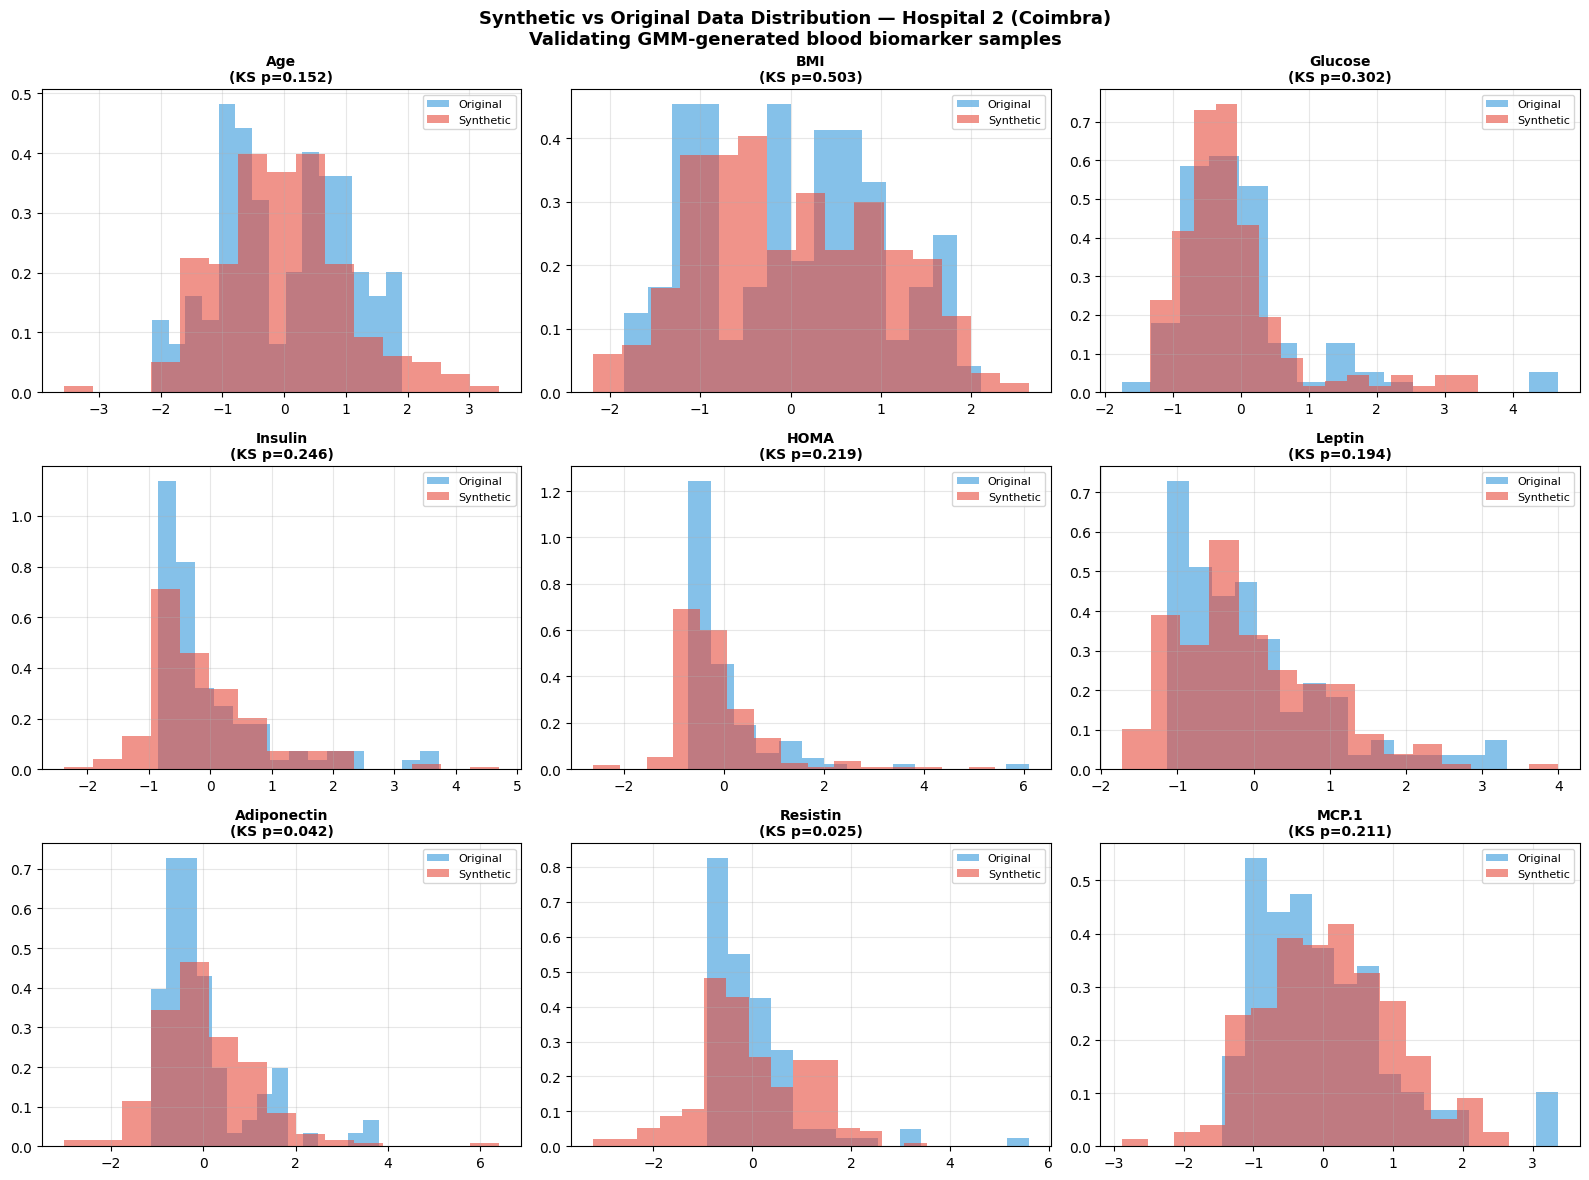


   Validation plot saved


In [ ]:
# ============================================================
# VALIDATE SYNTHETIC SAMPLES
# Ensure synthetic samples are realistic and within
# the original data distribution — not hallucinated
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

print("="*70)
print("  SYNTHETIC DATA VALIDATION")
print("="*70)

# Coimbra feature names
feature_names_h2 = [
    'Age', 'BMI', 'Glucose', 'Insulin',
    'HOMA', 'Leptin', 'Adiponectin',
    'Resistin', 'MCP.1'
]

# --------------------------------------------------------
# Statistical comparison: original vs synthetic
# --------------------------------------------------------
print("\n  Statistical comparison (original vs synthetic):")
print(f"  {'Feature':<15} {'Orig Mean':>12} "
      f"{'Syn Mean':>12} {'KS p-value':>12}")
print(f"  {'─'*55}")

ks_results = []
for i, feat in enumerate(feature_names_h2):
    orig_vals = X_train_h2[:, i]
    syn_vals  = np.vstack([
        X_syn_benign, X_syn_malignant
    ])[:, i]

    ks_stat, ks_pval = stats.ks_2samp(orig_vals, syn_vals)
    ks_results.append(ks_pval)

    status = '' if ks_pval > 0.05 else ''
    print(f"  {feat:<15} {orig_vals.mean():>12.4f} "
          f"{syn_vals.mean():>12.4f} "
          f"{ks_pval:>12.4f} {status}")

print(f"\n  KS test interpretation:")
print(f"  p > 0.05 → synthetic distribution matches original ")
print(f"  p < 0.05 → distribution differs significantly ")
print(f"  Features passing: "
      f"{sum(1 for p in ks_results if p > 0.05)}/{len(ks_results)}")

# --------------------------------------------------------
# Plot: Feature distribution comparison
# Original vs Synthetic per feature
# --------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle(
    'Synthetic vs Original Data Distribution — Hospital 2 (Coimbra)\n'
    'Validating GMM-generated blood biomarker samples',
    fontsize=13, fontweight='bold'
)

X_syn_all = np.vstack([X_syn_benign, X_syn_malignant])

for i, (ax, feat) in enumerate(
    zip(axes.flatten(), feature_names_h2)
):
    ax.hist(
        X_train_h2[:, i], bins=15,
        alpha=0.6, color='#3498DB',
        label='Original', density=True
    )
    ax.hist(
        X_syn_all[:, i], bins=15,
        alpha=0.6, color='#E74C3C',
        label='Synthetic', density=True
    )
    ax.set_title(
        f'{feat}\n(KS p={ks_results[i]:.3f})',
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    'results/synthetic_augmentation/'
    'feature_distribution_validation.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print("\n   Validation plot saved")

### Train H2 on Augmented Data

In [ ]:
# ============================================================
# TRAIN HOSPITAL 2 ON AUGMENTED DATASET
# Starting from FedAvg Equal best weights
# Fine-tune on augmented (original + synthetic) data
# ============================================================
import copy

print("="*70)
print("  TRAINING H2 ON AUGMENTED DATA")
print("="*70)

# Fresh model from FedAvg Equal best weights
model_h2_aug = Hospital2_MLP(
    input_size=9, dropout_rate=0.3
).to(device)
model_h2_aug.load_state_dict(
    torch.load(
        'models/federated/equal/best_h2_fedavg_eq.pth',
        map_location=device
    )
)

# --------------------------------------------------------
# Optimizers — unfreeze all layers
# Low LR to avoid catastrophic forgetting
# --------------------------------------------------------
optimizer_aug_enc  = optim.Adam(
    model_h2_aug.encoder.parameters(), lr=0.0005
)
optimizer_aug_head = optim.Adam(
    model_h2_aug.shared_head.parameters(), lr=0.0002
)
criterion = nn.BCEWithLogitsLoss()

# --------------------------------------------------------
# Training loop
# --------------------------------------------------------
aug_epochs     = 30
best_aug_acc   = 0.0
best_aug_state = None
aug_history    = {
    'epoch'   : [],
    'train_loss': [],
    'test_acc': [],
    'test_f1' : [],
    'test_auc': []
}

print(f"\n  Training for {aug_epochs} epochs on augmented data...")
print(f"  {'Epoch':<8} {'Train Loss':<12} "
      f"{'Test Acc':<12} {'Test F1':<12} {'Test AUC':<10}")
print(f"  {'─'*55}")

for epoch in range(aug_epochs):
    model_h2_aug.train()
    running_loss = 0.0
    all_preds    = []
    all_labels   = []

    for inputs, labels in aug_loader_h2:
        inputs = inputs.to(device).float()
        labels = labels.to(device).float().view(-1, 1)

        optimizer_aug_enc.zero_grad(set_to_none=True)
        optimizer_aug_head.zero_grad(set_to_none=True)

        outputs = model_h2_aug(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()

        optimizer_aug_enc.step()
        optimizer_aug_head.step()

        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(
            (outputs.detach() > 0.0).float().cpu().numpy()
        )
        all_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(aug_loader_h2.dataset)

    # Evaluate on ORIGINAL test set (not augmented)
    metrics = evaluate_model(model_h2_aug, test_loader_h2, device)

    aug_history['epoch'].append(epoch + 1)
    aug_history['train_loss'].append(train_loss)
    aug_history['test_acc'].append(metrics['accuracy'])
    aug_history['test_f1'].append(metrics['f1'])
    aug_history['test_auc'].append(metrics['auc_roc'])

    if metrics['accuracy'] > best_aug_acc:
        best_aug_acc   = metrics['accuracy']
        best_aug_state = copy.deepcopy(
            model_h2_aug.state_dict()
        )

    print(f"  {epoch+1:<8} {train_loss:<12.4f} "
          f"{metrics['accuracy']:<12.4f} "
          f"{metrics['f1']:<12.4f} "
          f"{metrics['auc_roc']:<10.4f}")

# Load best state
model_h2_aug.load_state_dict(best_aug_state)

print(f"\n   Training complete")
print(f"     Best accuracy  : {best_aug_acc:.4f}")
print(f"     Baseline was   : {baseline_metrics['accuracy']:.4f}")
print(f"     Improvement    : "
      f"{best_aug_acc - baseline_metrics['accuracy']:+.4f}")

# Save model
torch.save(
    model_h2_aug.state_dict(),
    'models/augmented/hospital2_augmented.pth'
)
print(f"     Model saved    : models/augmented/hospital2_augmented.pth")

  TRAINING H2 ON AUGMENTED DATA

  Training for 30 epochs on augmented data...
  Epoch    Train Loss   Test Acc     Test F1      Test AUC  
  ───────────────────────────────────────────────────────
  1        0.5250       0.7500       0.7500       0.7832    
  2        0.5668       0.7500       0.7500       0.7483    
  3        0.4945       0.7083       0.7200       0.7552    
  4        0.4840       0.7500       0.7500       0.7622    
  5        0.4314       0.7083       0.6957       0.7622    
  6        0.4518       0.7083       0.6957       0.7552    
  7        0.4714       0.7500       0.7500       0.7552    
  8        0.4710       0.7500       0.7500       0.7552    
  9        0.4496       0.7083       0.6957       0.7692    
  10       0.4571       0.7500       0.7500       0.7692    
  11       0.4677       0.7083       0.6957       0.7622    
  12       0.4322       0.7083       0.6957       0.7483    
  13       0.4148       0.7500       0.7500       0.7552    
  14     

### FL with Augmented H2

In [ ]:
# ============================================================
# FL ROUND WITH AUGMENTED HOSPITAL 2
# Run FedAvg Equal again but H2 uses augmented dataset
# This gives the full federated benefit + augmentation
# ============================================================
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

print("="*70)
print("  FL + SYNTHETIC AUGMENTATION (FedAvg Equal)")
print("="*70)

# Utility functions (same as previous notebooks)
def get_shared_head_weights(model):
    return {
        k: v.clone()
        for k, v in model.shared_head.state_dict().items()
    }

def set_shared_head_weights(model, weights):
    model.shared_head.load_state_dict(weights)

def federated_averaging(weights_list, dataset_sizes):
    total = sum(dataset_sizes)
    avg   = {}
    for key in weights_list[0].keys():
        avg[key] = sum(
            weights_list[i][key].float() *
            (dataset_sizes[i] / total)
            for i in range(len(weights_list))
        )
    return avg

def train_local_epoch(
    model, dataloader, criterion,
    optimizer_enc, optimizer_head, device
):
    model.train()
    running_loss = 0.0
    all_preds    = []
    all_labels   = []

    for inputs, labels in dataloader:
        inputs = inputs.to(device).float()
        labels = labels.to(device).float().view(-1, 1)

        optimizer_enc.zero_grad(set_to_none=True)
        optimizer_head.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()

        optimizer_enc.step()
        optimizer_head.step()

        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(
            (outputs.detach() > 0.0).float().cpu().numpy()
        )
        all_labels.extend(labels.cpu().numpy())

    return (
        running_loss / len(dataloader.dataset),
        accuracy_score(all_labels, all_preds)
    )

# --------------------------------------------------------
# Initialize models from Phase 3 trained weights
# --------------------------------------------------------
model_h1_fl = Hospital1_MLP(
    input_size=23, dropout_rate=0.3
).to(device)
model_h1_fl.load_state_dict(
    torch.load(
        'models/trained/hospital1_local.pth',
        map_location=device
    )
)

model_h2_fl = Hospital2_MLP(
    input_size=9, dropout_rate=0.3
).to(device)
model_h2_fl.load_state_dict(
    torch.load(
        'models/trained/hospital2_local.pth',
        map_location=device
    )
)

model_h3_fl = Hospital3_CNN(dropout_rate=0.2).to(device)
model_h3_fl.load_state_dict(
    torch.load(
        'models/trained/hospital3_local.pth',
        map_location=device
    )
)

# Optimizers
optimizer_h1_enc  = optim.Adam(
    model_h1_fl.encoder.parameters(), lr=0.001
)
optimizer_h1_head = optim.Adam(
    model_h1_fl.shared_head.parameters(), lr=0.0005
)
optimizer_h2_enc  = optim.Adam(
    model_h2_fl.encoder.parameters(), lr=0.001
)
optimizer_h2_head = optim.Adam(
    model_h2_fl.shared_head.parameters(), lr=0.0005
)
optimizer_h3_proj = optim.Adam(
    model_h3_fl.encoder.projection.parameters(), lr=0.0001
)
optimizer_h3_head = optim.Adam(
    model_h3_fl.shared_head.parameters(), lr=0.00005
)

criterion   = nn.BCEWithLogitsLoss()
equal_sizes = [1, 1, 1]

fl_history_aug = {
    'round'      : [],
    'h1_test_acc': [], 'h1_test_f1': [], 'h1_test_auc': [],
    'h2_test_acc': [], 'h2_test_f1': [], 'h2_test_auc': [],
    'h3_test_acc': [], 'h3_test_f1': [], 'h3_test_auc': [],
    'avg_test_acc': []
}

num_rounds   = 25
local_epochs = 2
best_fl_aug_loss = float('inf')

print(f"\n  Rounds       : {num_rounds}")
print(f"  Local epochs : {local_epochs}")
print(f"  H2 data      : {len(aug_dataset_h2)} (augmented)")
print(f"  Weighting    : Equal (33.3% each)\n")

for fl_round in range(num_rounds):

    # Local training
    h1_losses, h1_accs = [], []
    for _ in range(local_epochs):
        loss, acc = train_local_epoch(
            model_h1_fl, train_loader_h1, criterion,
            optimizer_h1_enc, optimizer_h1_head, device
        )
        h1_losses.append(loss)
        h1_accs.append(acc)

    h2_losses, h2_accs = [], []
    for _ in range(local_epochs):
        # H2 uses AUGMENTED loader
        loss, acc = train_local_epoch(
            model_h2_fl, aug_loader_h2, criterion,
            optimizer_h2_enc, optimizer_h2_head, device
        )
        h2_losses.append(loss)
        h2_accs.append(acc)

    h3_losses, h3_accs = [], []
    for _ in range(local_epochs):
        loss, acc = train_local_epoch(
            model_h3_fl, train_loader_h3, criterion,
            optimizer_h3_proj, optimizer_h3_head, device
        )
        h3_losses.append(loss)
        h3_accs.append(acc)

    # FedAvg equal
    global_weights = federated_averaging(
        [
            get_shared_head_weights(model_h1_fl),
            get_shared_head_weights(model_h2_fl),
            get_shared_head_weights(model_h3_fl)
        ],
        equal_sizes
    )

    set_shared_head_weights(model_h1_fl, global_weights)
    set_shared_head_weights(model_h2_fl, global_weights)
    set_shared_head_weights(model_h3_fl, global_weights)

    # Evaluate — H2 tested on ORIGINAL test set
    m1 = evaluate_model(model_h1_fl, test_loader_h1, device)
    m2 = evaluate_model(model_h2_fl, test_loader_h2, device)
    m3 = evaluate_model(model_h3_fl, test_loader_h3, device)

    avg_acc = np.mean([
        m1['accuracy'], m2['accuracy'], m3['accuracy']
    ])

    fl_history_aug['round'].append(fl_round + 1)
    fl_history_aug['h1_test_acc'].append(m1['accuracy'])
    fl_history_aug['h1_test_f1'].append(m1['f1'])
    fl_history_aug['h1_test_auc'].append(m1['auc_roc'])
    fl_history_aug['h2_test_acc'].append(m2['accuracy'])
    fl_history_aug['h2_test_f1'].append(m2['f1'])
    fl_history_aug['h2_test_auc'].append(m2['auc_roc'])
    fl_history_aug['h3_test_acc'].append(m3['accuracy'])
    fl_history_aug['h3_test_f1'].append(m3['f1'])
    fl_history_aug['h3_test_auc'].append(m3['auc_roc'])
    fl_history_aug['avg_test_acc'].append(avg_acc)

    avg_loss = np.mean([m1['loss'], m2['loss'], m3['loss']])
    if avg_loss < best_fl_aug_loss:
        best_fl_aug_loss = avg_loss
        torch.save(
            model_h1_fl.state_dict(),
            'models/augmented/best_h1_fl_aug.pth'
        )
        torch.save(
            model_h2_fl.state_dict(),
            'models/augmented/best_h2_fl_aug.pth'
        )
        torch.save(
            model_h3_fl.state_dict(),
            'models/augmented/best_h3_fl_aug.pth'
        )
        torch.save(
            global_weights,
            'models/augmented/best_global_head_aug.pth'
        )

    if (fl_round + 1) % 5 == 0 or fl_round == 0:
        print(f"  Round {fl_round+1:02d} | "
              f"H1={m1['accuracy']:.4f} "
              f"H2={m2['accuracy']:.4f} "
              f"H3={m3['accuracy']:.4f} "
              f"Avg={avg_acc:.4f}")

# Save history
aug_history_serializable = {
    k: [float(v) for v in vals]
    if isinstance(vals[0], (float, int, np.floating, np.integer))
    else vals
    for k, vals in fl_history_aug.items()
}
with open(
    'results/synthetic_augmentation/fl_history_aug.json',
    'w', encoding='utf-8'
) as f:
    json.dump(aug_history_serializable, f, indent=4)

best_idx_aug = int(np.argmax(fl_history_aug['avg_test_acc']))
print(f"\n   FL + Augmentation complete")
print(f"     Best H2 accuracy : "
      f"{max(fl_history_aug['h2_test_acc']):.4f}")
print(f"     Baseline was     : "
      f"{max(fl_history_equal['h2_test_acc']):.4f}")
print(f"     Improvement      : "
      f"{max(fl_history_aug['h2_test_acc'])-max(fl_history_equal['h2_test_acc']):+.4f}")

  FL + SYNTHETIC AUGMENTATION (FedAvg Equal)

  Rounds       : 25
  Local epochs : 2
  H2 data      : 300 (augmented)
  Weighting    : Equal (33.3% each)

  Round 01 | H1=0.9298 H2=0.7917 H3=0.9569 Avg=0.8928
  Round 05 | H1=0.9737 H2=0.7083 H3=0.9744 Avg=0.8855
  Round 10 | H1=0.9561 H2=0.7083 H3=0.9919 Avg=0.8855
  Round 15 | H1=0.9561 H2=0.6667 H3=0.9865 Avg=0.8698
  Round 20 | H1=0.9561 H2=0.6667 H3=0.9919 Avg=0.8716
  Round 25 | H1=0.9561 H2=0.7083 H3=0.9906 Avg=0.8850

   FL + Augmentation complete
     Best H2 accuracy : 0.7917
     Baseline was     : 0.7917
     Improvement      : +0.0000


### Plot: Augmentation Results

Generating augmentation plots...


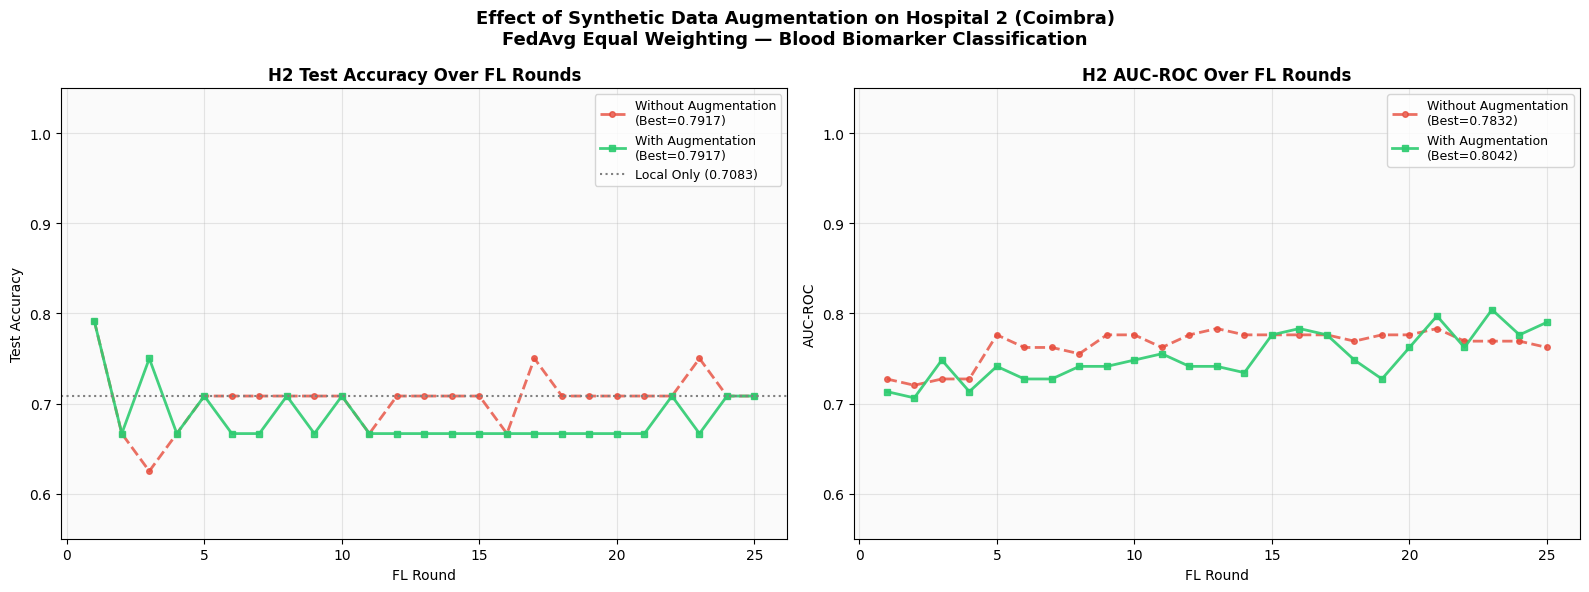

   Plot 1 saved: h2_augmentation_improvement.png


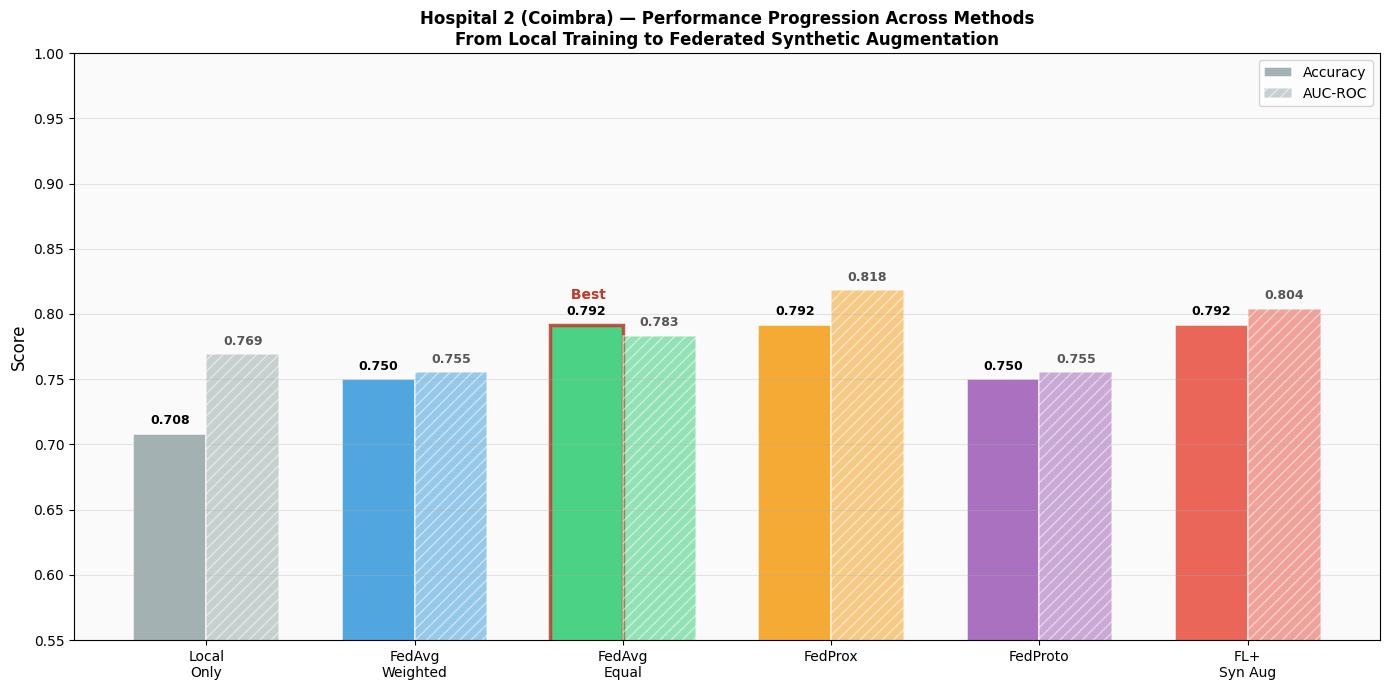

   Plot 2 saved: h2_all_methods_progression.png


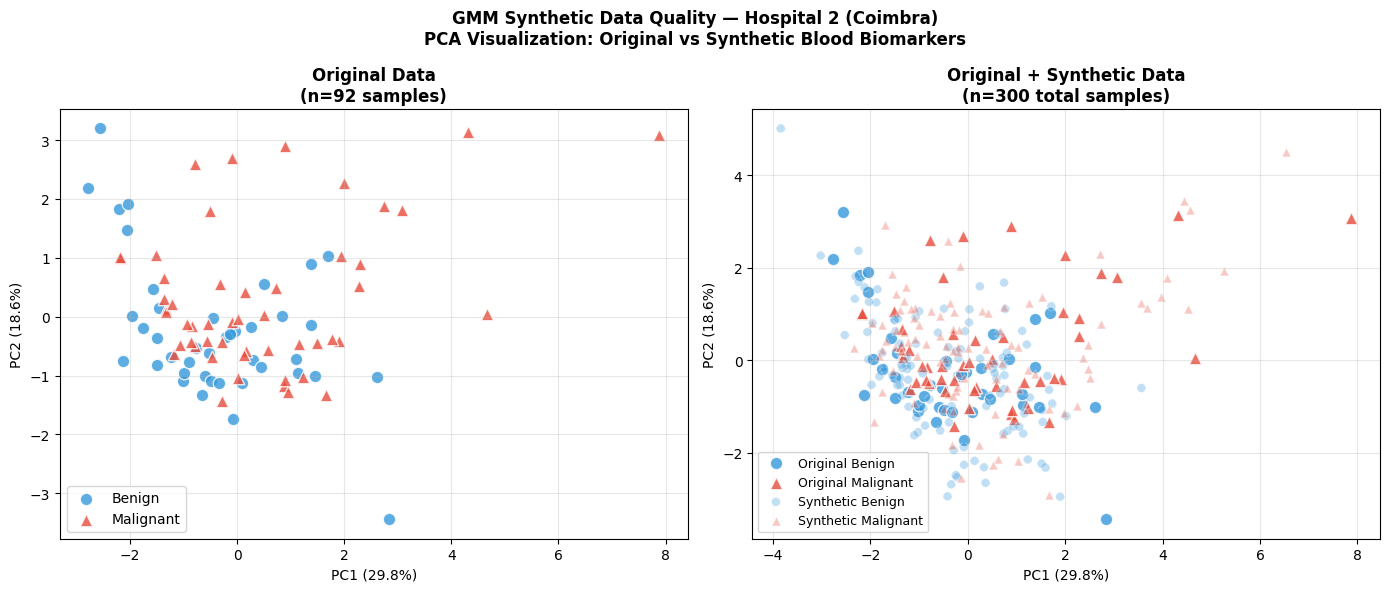

   Plot 3 saved: pca_synthetic_visualization.png


In [ ]:
# ============================================================
# PAPER-QUALITY PLOTS — SYNTHETIC AUGMENTATION
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("Generating augmentation plots...")

best_idx_aug      = int(np.argmax(fl_history_aug['avg_test_acc']))
best_idx_baseline = int(np.argmax(fl_history_equal['avg_test_acc']))

# --------------------------------------------------------
# Plot 1 — H2 Accuracy: Before vs After Augmentation
# Across FL rounds
# --------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Effect of Synthetic Data Augmentation on Hospital 2 (Coimbra)\n'
    'FedAvg Equal Weighting — Blood Biomarker Classification',
    fontsize=13, fontweight='bold'
)

# Left: H2 accuracy over rounds
axes[0].plot(
    fl_history_equal['round'],
    fl_history_equal['h2_test_acc'],
    color='#E74C3C', linewidth=2,
    linestyle='--', marker='o', markersize=4,
    label=f'Without Augmentation\n'
          f'(Best={max(fl_history_equal["h2_test_acc"]):.4f})',
    alpha=0.8
)
axes[0].plot(
    fl_history_aug['round'],
    fl_history_aug['h2_test_acc'],
    color='#2ECC71', linewidth=2,
    linestyle='-', marker='s', markersize=4,
    label=f'With Augmentation\n'
          f'(Best={max(fl_history_aug["h2_test_acc"]):.4f})',
    alpha=0.9
)
axes[0].axhline(
    y=0.7083, color='gray', linewidth=1.5,
    linestyle=':', label='Local Only (0.7083)'
)
axes[0].set_title(
    'H2 Test Accuracy Over FL Rounds',
    fontweight='bold'
)
axes[0].set_xlabel('FL Round')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim([0.55, 1.05])
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#FAFAFA')

# Right: H2 AUC over rounds
axes[1].plot(
    fl_history_equal['round'],
    fl_history_equal['h2_test_auc'],
    color='#E74C3C', linewidth=2,
    linestyle='--', marker='o', markersize=4,
    label=f'Without Augmentation\n'
          f'(Best={max(fl_history_equal["h2_test_auc"]):.4f})',
    alpha=0.8
)
axes[1].plot(
    fl_history_aug['round'],
    fl_history_aug['h2_test_auc'],
    color='#2ECC71', linewidth=2,
    linestyle='-', marker='s', markersize=4,
    label=f'With Augmentation\n'
          f'(Best={max(fl_history_aug["h2_test_auc"]):.4f})',
    alpha=0.9
)
axes[1].set_title(
    'H2 AUC-ROC Over FL Rounds',
    fontweight='bold'
)
axes[1].set_xlabel('FL Round')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim([0.55, 1.05])
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig(
    'results/synthetic_augmentation/'
    'h2_augmentation_improvement.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print("   Plot 1 saved: h2_augmentation_improvement.png")

# --------------------------------------------------------
# Plot 2 — All Methods Comparison: H2 Performance
# Full progression from Local to Augmented
# --------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

methods = [
    'Local\nOnly',
    'FedAvg\nWeighted',
    'FedAvg\nEqual',
    'FedProx',
    'FedProto',
    'FL+\nSyn Aug'
]

with open('results/federated/fl_history.json', 'r') as f:
    fl_hist_w = json.load(f)
with open(
    'results/federated/fedprox/fl_history_prox.json', 'r'
) as f:
    fl_hist_prox = json.load(f)
with open(
    'results/federated/fedproto/fl_history_fedproto.json', 'r'
) as f:
    fl_hist_proto = json.load(f)

h2_accs = [
    0.7083,
    max(fl_hist_w['h2_test_acc']),
    max(fl_history_equal['h2_test_acc']),
    max(fl_hist_prox['h2_test_acc']),
    max(fl_hist_proto['h2_test_acc']),
    max(fl_history_aug['h2_test_acc'])
]
h2_aucs = [
    0.7692,
    max(fl_hist_w['h2_test_auc']),
    max(fl_history_equal['h2_test_auc']),
    max(fl_hist_prox['h2_test_auc']),
    max(fl_hist_proto['h2_test_auc']),
    max(fl_history_aug['h2_test_auc'])
]

x     = np.arange(len(methods))
width = 0.35

bar_colors_acc = [
    '#95A5A6', '#3498DB', '#2ECC71',
    '#F39C12', '#9B59B6', '#E74C3C'
]

bars1 = ax.bar(
    x - width/2, h2_accs, width,
    color=bar_colors_acc, alpha=0.85,
    edgecolor='white', linewidth=1.2,
    label='Accuracy'
)
bars2 = ax.bar(
    x + width/2, h2_aucs, width,
    color=bar_colors_acc, alpha=0.5,
    edgecolor='white', linewidth=1.2,
    hatch='///', label='AUC-ROC'
)

for bar in bars1:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., h + 0.005,
        f'{h:.3f}', ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
for bar in bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., h + 0.005,
        f'{h:.3f}', ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#555'
    )

ax.set_title(
    'Hospital 2 (Coimbra) — Performance Progression Across Methods\n'
    'From Local Training to Federated Synthetic Augmentation',
    fontsize=12, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim([0.55, 1.0])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#FAFAFA')

# Highlight best method
best_bar_idx = np.argmax(h2_accs)
axes_rect    = plt.gca()
bars1[best_bar_idx].set_edgecolor('#C0392B')
bars1[best_bar_idx].set_linewidth(2.5)
ax.annotate(
    ' Best',
    xy=(x[best_bar_idx] - width/2,
        h2_accs[best_bar_idx] + 0.02),
    ha='center', fontsize=10,
    color='#C0392B', fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    'results/synthetic_augmentation/'
    'h2_all_methods_progression.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print("   Plot 2 saved: h2_all_methods_progression.png")

# --------------------------------------------------------
# Plot 3 — GMM Synthetic Data Visualization
# 2D PCA of original vs synthetic samples
# --------------------------------------------------------
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'GMM Synthetic Data Quality — Hospital 2 (Coimbra)\n'
    'PCA Visualization: Original vs Synthetic Blood Biomarkers',
    fontsize=12, fontweight='bold'
)

pca = PCA(n_components=2, random_state=42)

# Fit PCA on original data only
X_all_for_pca = np.vstack([
    X_train_h2, X_syn_benign, X_syn_malignant
])
pca.fit(X_all_for_pca)

orig_pca   = pca.transform(X_train_h2)
syn_pca    = pca.transform(
    np.vstack([X_syn_benign, X_syn_malignant])
)

y_syn_all  = np.concatenate([y_syn_benign, y_syn_malignant])

# Left: Original data
axes[0].scatter(
    orig_pca[y_train_h2==0, 0],
    orig_pca[y_train_h2==0, 1],
    c='#3498DB', alpha=0.8, s=80,
    label='Benign', marker='o', edgecolors='white'
)
axes[0].scatter(
    orig_pca[y_train_h2==1, 0],
    orig_pca[y_train_h2==1, 1],
    c='#E74C3C', alpha=0.8, s=80,
    label='Malignant', marker='^', edgecolors='white'
)
axes[0].set_title(
    f'Original Data\n(n={len(X_train_h2)} samples)',
    fontweight='bold'
)
axes[0].legend(fontsize=10)
axes[0].set_xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)'
)
axes[0].set_ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
)
axes[0].grid(True, alpha=0.3)

# Right: Original + Synthetic
axes[1].scatter(
    orig_pca[y_train_h2==0, 0],
    orig_pca[y_train_h2==0, 1],
    c='#3498DB', alpha=0.8, s=80,
    label='Original Benign', marker='o', edgecolors='white'
)
axes[1].scatter(
    orig_pca[y_train_h2==1, 0],
    orig_pca[y_train_h2==1, 1],
    c='#E74C3C', alpha=0.8, s=80,
    label='Original Malignant', marker='^', edgecolors='white'
)
axes[1].scatter(
    syn_pca[y_syn_all==0, 0],
    syn_pca[y_syn_all==0, 1],
    c='#3498DB', alpha=0.3, s=40,
    label='Synthetic Benign', marker='o',
    edgecolors='white', linestyle='dashed'
)
axes[1].scatter(
    syn_pca[y_syn_all==1, 0],
    syn_pca[y_syn_all==1, 1],
    c='#E74C3C', alpha=0.3, s=40,
    label='Synthetic Malignant', marker='^',
    edgecolors='white'
)
axes[1].set_title(
    f'Original + Synthetic Data\n'
    f'(n={len(X_train_h2_aug)} total samples)',
    fontweight='bold'
)
axes[1].legend(fontsize=9)
axes[1].set_xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)'
)
axes[1].set_ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    'results/synthetic_augmentation/'
    'pca_synthetic_visualization.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print("   Plot 3 saved: pca_synthetic_visualization.png")